Suppose customer data contains:
```
Premium Customers
Budget Customers
Occasional Customers
```
True number of groups:
```
3
```
If:
```
K = 2
```
Different customer types get merged.

If:
```
K = 20
```
Meaningful groups get fragmented.

Choosing K incorrectly can completely invalidate clustering results.

### What Makes a Good Clustering?
Good clustering should have:

#### High Cohesion
Points inside a cluster should be close.

#### High Separation
Different clusters should be far apart.

Mathematically:
```
Small intra-cluster distance
Large inter-cluster distance
```

### Why WCSS Always Decreases
K-Means minimizes:
$$
WCSS = \sum_{x \in C_i} \|x - \mu_i\|^2
$$
Also called:
- Inertia
- Within Cluster Sum of Squares

As K increases:
```
More centroids
Smaller distances
```
Therefore:
$$
WCSS↓
$$
always decreases.

Example:
| K | WCSS  |
| - | ----- |
| 1 | 10000 |
| 2 | 5000  |
| 3 | 2500  |
| 4 | 1500  |
| 5 | 1200  |
| 6 | 1000  |

**Problem:** WCSS never tells when to stop.

#### Method 1 — Elbow Method
Most common approach.

##### Core Idea
Plot:
```
K
vs
WCSS
```
Example:
| K | WCSS  |
| - | ----- |
| 1 | 10000 |
| 2 | 5000  |
| 3 | 2500  |
| 4 | 1400  |
| 5 | 1300  |
| 6 | 1250  |

Look for: **Elbow Point**

The point where improvement slows dramatically.

Interpretation:
```
Before elbow:
Big improvement

After elbow:
Small improvement
```

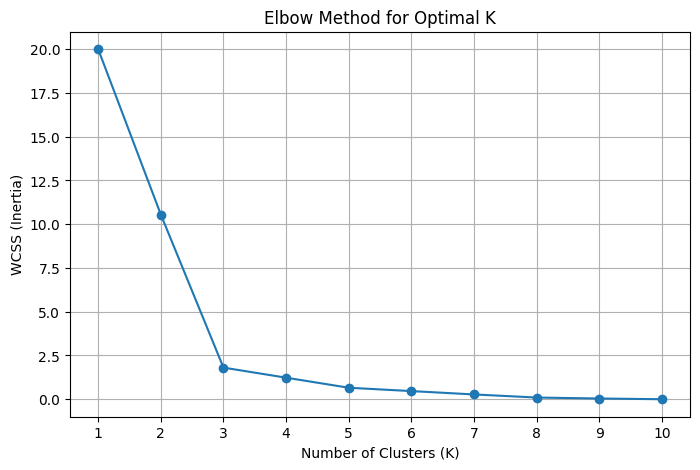

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Sample Dataset
X = np.array([
    [1, 2],
    [1, 4],
    [1, 0],
    [10, 2],
    [10, 4],
    [10, 0],
    [5, 8],
    [6, 9],
    [5, 7],
    [6, 8]
])

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # WCSS

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

##### Limitation of Elbow Method
Many datasets:
```
No obvious elbow
```
Decision becomes subjective.

#### Method 2 — Silhouette Score
More mathematically rigorous.

##### Core Idea
Measures:
```
Cluster Cohesion
+
Cluster Separation
```
simultaneously.

**Silhouette Formula**

For a sample:
$$
s = \frac{b - a}{max(a, b)}
$$

Where:
- a = Average distance to points in same cluster.
- b = Average distance to nearest other cluster.

**Interpretation**

Range:
$$
−1≤s≤1
$$

##### Silhouette Interpretation Table
| Score     | Meaning   |
| --------- | --------- |
| 0.70–1.00 | Excellent |
| 0.50–0.70 | Good      |
| 0.25–0.50 | Weak      |
| <0.25     | Poor      |

##### Why Silhouette Is Better
Unlike WCSS:

Silhouette considers:
- Compactness
- Separation

Therefore: More reliable.

#### Method 3 — Gap Statistic
More advanced.

Common in research and analytics.

##### Core Idea
Compare:
```
Actual clustering
```
against
```
Randomly generated data
```
If clustering significantly better than random:

Good K.

**Gap Statistic Formula**
$$
Gap(k) = E[\log(W_k)] - log(W_k)
$$

Where:
- $W_k$ = observed WCSS
- $E[\log(W_k)]$ = expected WCSS under random distribution

Choose K with: **Largest gap**.

##### Why Gap Statistic Is Powerful
Accounts for:
```
Data randomness
```
which Elbow Method ignores.

##### Limitation
Computationally expensive.

Requires:

Multiple random datasets.

### Comparing Methods
| Method        | Easy      | Reliable | Production Usage |
| ------------- | --------- | -------- | ---------------- |
| Elbow         | Very Easy | Moderate | High             |
| Silhouette    | Easy      | High     | Very High        |
| Gap Statistic | Moderate  | High     | Medium           |

### Typical Flow
Typical process:
```
Scale Data
 ↓
Try K=2..15
 ↓
Elbow Method
 ↓
Silhouette Score
 ↓
Business Validation
```